In [7]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt


In [17]:
print(df1.columns)

Index(['Channel Name', 'Subscriber Count', 'Total Videos', 'Total Views',
       'View Count', 'Like Count', 'Comment Count', 'Video Posted',
       'Video Link'],
      dtype='object')


In [19]:
 import pandas as pd

# Suppose df_merged is your merged dataframe of the same videos across two snapshots
# For demonstration, let's create new columns that capture changes between wk1 and wk2.

# 1) Subscriber Growth (absolute)
df_merged["SubscriberGrowth"] = df_merged["Subscriber Count_wk2"] - df_merged["Subscriber Count_wk1"]

# 2) Subscriber Growth Ratio (relative)
df_merged["SubscriberGrowthRatio"] = (
    df_merged["Subscriber Count_wk2"] / df_merged["Subscriber Count_wk1"] - 1
).replace([float('inf'), -float('inf')], float('nan'))

# 3) Total Views Growth (absolute)
df_merged["TotalViewsGrowth"] = df_merged["Total Views_wk2"] - df_merged["Total Views_wk1"]

# 4) Total Views Growth per Video
#    Sometimes normalizing by the # of videos can help if big channels keep posting new videos
df_merged["ViewsGrowthPerVideo"] = (
    df_merged["TotalViewsGrowth"] / (df_merged["Total Videos_wk2"] + 1e-6)
)

# 5) Additional "growth" columns if you want to predict "View Count_wk2"
df_merged["ViewCountGrowth"] = df_merged["View Count_wk2"] - df_merged["View Count_wk1"]
df_merged["LikeCountGrowth"] = df_merged["Like Count_wk2"] - df_merged["Like Count_wk1"]
df_merged["CommentCountGrowth"] = df_merged["Comment Count_wk2"] - df_merged["Comment Count_wk1"]

# 6) Ratios or rates (like "likes per view" at wk1)
df_merged["LikeToViewRatio_wk1"] = (
    df_merged["Like Count_wk1"] / (df_merged["View Count_wk1"] + 1e-6)
)
df_merged["CommentToViewRatio_wk1"] = (
    df_merged["Comment Count_wk1"] / (df_merged["View Count_wk1"] + 1e-6)
)

# Now you have a bunch of new features capturing changes over time
print("=== HEAD OF DF WITH NEW FEATURES ===")
print(df_merged.head())


=== HEAD OF DF WITH NEW FEATURES ===
        Channel Name_wk1  Subscriber Count_wk1  Total Videos_wk1  \
0  The Infographics Show              14800000              5354   
1  The Infographics Show              14800000              5354   
2  The Infographics Show              14800000              5354   
3  The Infographics Show              14800000              5354   
4  The Infographics Show              14800000              5354   

   Total Views_wk1  View Count_wk1  Like Count_wk1  Comment Count_wk1  \
0       6251451295         14149.0             936                225   
1       6251451295        267615.0            9021               1621   
2       6251451295         25730.0             338                 26   
3       6251451295         67402.0            1721                193   
4       6251451295         90882.0            3079                442   

       Video Posted_wk1                                         Video Link  \
0  2025-02-11T00:11:00Z  https://www.

In [23]:
import pandas as pd

###############################################################################
# PART 1: MERGE & SUMMARIES
###############################################################################

# 1) Load the two CSVs
df1 = pd.read_csv("526 1.csv")
df2 = pd.read_csv("526 2.csv")

# 2) Merge on a unique key, e.g. "Video Link" (adjust if your key is different)
#    Suffixes let us distinguish columns from week1 vs. week2
df_merged = pd.merge(df1, df2, on="Video Link", suffixes=("_wk1", "_wk2"))

# 3) Convert numeric columns to numeric (in case there are hidden strings)
numeric_cols_wk1 = ["Subscriber Count_wk1", "Total Videos_wk1", "Total Views_wk1",
                    "View Count_wk1", "Like Count_wk1", "Comment Count_wk1"]
numeric_cols_wk2 = ["Subscriber Count_wk2", "Total Videos_wk2", "Total Views_wk2",
                    "View Count_wk2", "Like Count_wk2", "Comment Count_wk2"]

for col in numeric_cols_wk1 + numeric_cols_wk2:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

df_merged.dropna(subset=numeric_cols_wk1 + numeric_cols_wk2, inplace=True)

# 4) Create "growth" or "change" columns from week1 to week2
df_merged["View Count Growth"] = df_merged["View Count_wk2"] - df_merged["View Count_wk1"]
df_merged["Like Count Growth"] = df_merged["Like Count_wk2"] - df_merged["Like Count_wk1"]
df_merged["Comment Count Growth"] = df_merged["Comment Count_wk2"] - df_merged["Comment Count_wk1"]

# 5) Basic summary of these new growth columns
print("\n=== GROWTH SUMMARY (WEEK1 -> WEEK2) ===")
print(df_merged[["View Count Growth", "Like Count Growth", "Comment Count Growth"]].describe())

# 6) Optional: look at a few rows to confirm the merge
print("\n=== SAMPLE ROWS AFTER MERGE ===")
print(df_merged.head())

print("\nPart 1 complete. Provide this summary output to see how your data changed over two weeks.")



=== GROWTH SUMMARY (WEEK1 -> WEEK2) ===
       View Count Growth  Like Count Growth  Comment Count Growth
count       2.680000e+02         268.000000            268.000000
mean        7.612290e+04        1565.190299             81.735075
std         3.487167e+05        9708.292195            414.649783
min         2.400000e+01           0.000000            -10.000000
25%         1.075250e+03          22.000000              0.000000
50%         5.716000e+03         119.500000              3.000000
75%         3.371550e+04         705.500000             30.500000
max         5.012161e+06      154383.000000           5902.000000

=== SAMPLE ROWS AFTER MERGE ===
        Channel Name_wk1  Subscriber Count_wk1  Total Videos_wk1  \
0  The Infographics Show              14800000              5354   
1  The Infographics Show              14800000              5354   
2  The Infographics Show              14800000              5354   
3  The Infographics Show              14800000              

In [25]:
import statsmodels.api as sm
import numpy as np

###############################################################################
# PART 2: REGRESSION TO DETECT A SIGNAL
###############################################################################

# We assume you already ran Part 1, so df_merged is in memory.

# 1) Pick some features from the *first* week that might predict growth
features = ["Subscriber Count_wk1", "Total Videos_wk1", "Total Views_wk1",]

# 2) Our target is "View Count Growth"
target = "View Count_wk2"

# 3) Extract X and y
X = df_merged[features]
y = df_merged[target]

# 4) Add intercept for regression
X = sm.add_constant(X)

# 5) Fit a simple OLS model
model = sm.OLS(y, X).fit()

# 6) Show regression results
print("\n=== REGRESSION: PREDICTING VIEW COUNT GROWTH FROM WEEK1 FEATURES ===")
print(model.summary())

# 7) Interpretation:
#    - If, for example, "Subscriber Count_wk1" has a positive, significant
#      coefficient, that suggests channels with higher subscriber counts at week1
#      tend to have larger gains in view count over the 2-week span.
#    - This can be presented as a "signal" that you discovered in the data.

print("\nPart 2 complete. Look at the regression summary for a potential 'signal'!")



=== REGRESSION: PREDICTING VIEW COUNT GROWTH FROM WEEK1 FEATURES ===
                            OLS Regression Results                            
Dep. Variable:         View Count_wk2   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     18.16
Date:                Wed, 05 Mar 2025   Prob (F-statistic):           9.64e-11
Time:                        18:58:47   Log-Likelihood:                -4085.1
No. Observations:                 268   AIC:                             8178.
Df Residuals:                     264   BIC:                             8193.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [28]:
###############################################################################
# SETUP: Common Imports
###############################################################################
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

###############################################################################
# We assume you already have a merged DataFrame `df_merged` with columns from:
#   "526 1.csv"  -> (e.g. "..._wk1")
#   "526 2.csv"  -> (e.g. "..._wk2")
# plus any computed columns like "View Growth", "View Growth Ratio", etc.
# We'll just reference df_merged in the examples below.
###############################################################################


###############################################################################
# METHOD 1: Time-Series or Trend-Focused Methods
# (Toy Example with statsmodels ARIMA or Prophet-like approach)
# NOTE: If you only have 2 snapshots, you can't really do a time-series.
# This snippet assumes you have multiple time points (df_time).
###############################################################################

# EXAMPLE: Suppose we have a "daily" timeseries of total channel views
# in a DataFrame `df_time` with columns: ["date", "channel", "daily_views"].
# We'll do a quick ARIMA for one channel. This is just demonstration code.

def method_1_timeseries_example(df_time):
    # Filter one channel (or sum across channels)
    channel_data = df_time[df_time["channel"] == "SomeChannel"].copy()
    
    # Sort by date, set index
    channel_data = channel_data.sort_values("date").set_index("date")
    
    # statsmodels wants a numeric Series
    y = channel_data["daily_views"].asfreq("D")  # daily frequency
    
    # Fill missing days if needed
    y = y.fillna(method="ffill")
    
    # ARIMA example (p, d, q) = (1, 1, 1)
    from statsmodels.tsa.arima.model import ARIMA
    model = ARIMA(y, order=(1,1,1))
    result = model.fit()
    print(result.summary())
    
    # Forecast next 7 days
    forecast = result.forecast(steps=7)
    print("\nTime-Series Forecast (Next 7 days):")
    print(forecast)


###############################################################################
# METHOD 2: Hierarchical (Multi-Level) Modeling
# Example: Predict "View Growth" with random intercepts by Channel.
# We'll use a statsmodels MixedLM or a Bayesian approach in PyMC.
###############################################################################

def method_2_hierarchical_model(df_merged):
    # Suppose each row is a video, with "Channel Name", "Subscriber Count_wk1", "View Growth"
    # We'll do a minimal example with statsmodels MixedLM (random intercept for each channel).
    
    # Create numeric ID for channels
    df_merged["channel_id"] = df_merged["Channel Name"].astype("category").cat.codes
    
    # We'll do a formula: ViewGrowth ~ SubscriberCount_wk1 + (1|channel_id)
    # In statsmodels, MixedLM syntax is different than formula API:
    endog = df_merged["View Growth"]
    exog = sm.add_constant(df_merged["Subscriber Count_wk1"])
    groups = df_merged["channel_id"]  # random intercept grouping
    
    md = sm.MixedLM(endog, exog, groups=groups)
    mdf = md.fit()
    print(mdf.summary())


###############################################################################
# METHOD 3: Clustering & Unsupervised Methods
# Example: K-Means Clustering on some features, then compare average growth.
###############################################################################

def method_3_clustering(df_merged):
    from sklearn.cluster import KMeans
    
    # We'll cluster videos by a few features (wk1 metrics).
    features = ["Subscriber Count_wk1", "View Count_wk1", "Like Count_wk1"]
    X = df_merged[features].copy()
    
    # KMeans with 3 clusters
    kmeans = KMeans(n_clusters=3, random_state=42)
    df_merged["cluster"] = kmeans.fit_predict(X)
    
    # Compare average "View Growth" in each cluster
    cluster_means = df_merged.groupby("cluster")["View Growth"].mean()
    print("\n=== K-Means Clusters: Average View Growth by Cluster ===")
    print(cluster_means)
    
    # Optionally plot cluster membership
    sns.scatterplot(data=df_merged, x="Subscriber Count_wk1", y="View Growth",
                    hue="cluster", palette="viridis")
    plt.title("K-Means Clusters")
    plt.show()


###############################################################################
# METHOD 4: Permutation Tests or Non-Parametric Approaches
# Example: Permutation test for correlation between "Like Count_wk1" and "View Growth".
###############################################################################

def method_4_permutation_test(df_merged, n_perm=1000):
    import random
    
    x = df_merged["Like Count_wk1"].values
    y = df_merged["View Growth"].values
    
    # Observed correlation (Pearson)
    obs_corr = np.corrcoef(x, y)[0,1]
    
    # Permutation test: shuffle x many times
    count_more_extreme = 0
    for _ in range(n_perm):
        x_perm = np.random.permutation(x)
        perm_corr = np.corrcoef(x_perm, y)[0,1]
        if abs(perm_corr) >= abs(obs_corr):
            count_more_extreme += 1
    
    p_value = count_more_extreme / n_perm
    print(f"\n=== PERMUTATION TEST ===")
    print(f"Observed correlation = {obs_corr:.3f}")
    print(f"P-value (two-sided) ~ {p_value:.3f} (n_perm={n_perm})")


###############################################################################
# METHOD 5: Interaction Terms & Polynomial Terms
# Example: OLS with an interaction: (SubscriberCount_wk1 * LikeCount_wk1)
###############################################################################

def method_5_interactions(df_merged):
    # We'll do a formula approach in statsmodels
    # We'll predict "View Growth" from "Subscriber Count_wk1", "Like Count_wk1", plus their interaction.
    
    # In formula: "x1:x2" means interaction, "x1*x2" means x1 + x2 + x1:x2
    formula = "Q('View Growth') ~ Q('Subscriber Count_wk1') * Q('Like Count_wk1')"
    model = smf.ols(formula=formula, data=df_merged).fit()
    print("\n=== OLS WITH INTERACTION ===")
    print(model.summary())


###############################################################################
# METHOD 6: Advanced Tree/Boosting Methods & Model Interpretation
# Example: Gradient Boosting + SHAP values
###############################################################################

def method_6_boosting_shap(df_merged):
    # We'll do a quick example with scikit-learn's GradientBoostingRegressor
    # Then use shap for interpretability.
    from sklearn.ensemble import GradientBoostingRegressor
    import shap
    
    # Suppose we want to predict "View Growth Ratio" from some wk1 features
    features = ["Subscriber Count_wk1", "View Count_wk1", "Like Count_wk1"]
    target = "View Growth Ratio"
    
    df_merged = df_merged.dropna(subset=features + [target])
    X = df_merged[features]
    y = df_merged[target]
    
    gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gbr.fit(X, y)
    
    # Evaluate quickly
    preds = gbr.predict(X)
    mse = np.mean((preds - y)**2)
    r2 = 1 - np.sum((preds-y)**2)/np.sum((y-y.mean())**2)
    
    print("\n=== GRADIENT BOOSTING REGRESSOR ===")
    print(f"MSE: {mse:.3f}, R^2: {r2:.3f}")
    
    # SHAP for interpretability
    explainer = shap.Explainer(gbr, X)
    shap_values = explainer(X)
    
    # Summary plot
    shap.summary_plot(shap_values, X, show=False)
    plt.title("SHAP Summary: Feature Importance")
    plt.show()


###############################################################################
# METHOD 7: Causal Inference Techniques (Difference-in-Differences)
# Example: If some videos changed a thumbnail at wk1 (treated) vs. didn't (control).
# We'll do a minimal example with linearmodels library (pip install linearmodels).
###############################################################################

def method_7_diff_in_diff(df_diff):
    # This code requires a DataFrame with columns:
    #   "treated" (boolean 0/1 if video changed thumbnail)
    #   "time" (0 for pre, 1 for post)
    #   "outcome" (views or something)
    #   "entity" (video ID or channel)
    # In your real data, you'd reshape so you have pre vs. post for each video.
    # We'll do a toy example.
    from linearmodels import DifferenceInDifferences
    
    # Example data structure:
    # df_diff = pd.DataFrame({
    #   "entity": [...],
    #   "time": [...],  # 0 or 1
    #   "treated": [...], # 0 or 1
    #   "outcome": [...]
    # })
    
    # We'll specify a formula: outcome ~ 1 + treated + time + treated:time
    exog = sm.add_constant(df_diff[["treated","time","treated:time"]])
    mod = DifferenceInDifferences(
        df_diff["outcome"], exog,
        groups=df_diff["entity"],  # fixed effects for each entity
        time=df_diff["time"]
    )
    res = mod.fit(cov_type="clustered", clusters=df_diff["entity"])
    print("\n=== DIFFERENCE-IN-DIFFERENCES RESULTS ===")
    print(res)


###############################################################################
# HOW TO RUN:
# - Adapt each method function call to your data.
# - For example, if you want to do hierarchical modeling:
#       method_2_hierarchical_model(df_merged)
# - If you want to do random forest + shap:
#       method_6_boosting_shap(df_merged)
###############################################################################


=== HEAD OF MERGED DATA (WITH GROWTH COLUMNS) ===
        Channel Name_wk1  Subscriber Count_wk1  Total Videos_wk1  \
0  The Infographics Show              14800000              5354   
1  The Infographics Show              14800000              5354   
2  The Infographics Show              14800000              5354   
3  The Infographics Show              14800000              5354   
4  The Infographics Show              14800000              5354   

   Total Views_wk1  View Count_wk1  Like Count_wk1  Comment Count_wk1  \
0       6251451295         14149.0             936                225   
1       6251451295        267615.0            9021               1621   
2       6251451295         25730.0             338                 26   
3       6251451295         67402.0            1721                193   
4       6251451295         90882.0            3079                442   

       Video Posted_wk1                                         Video Link  \
0  2025-02-11T00:11:00Z 

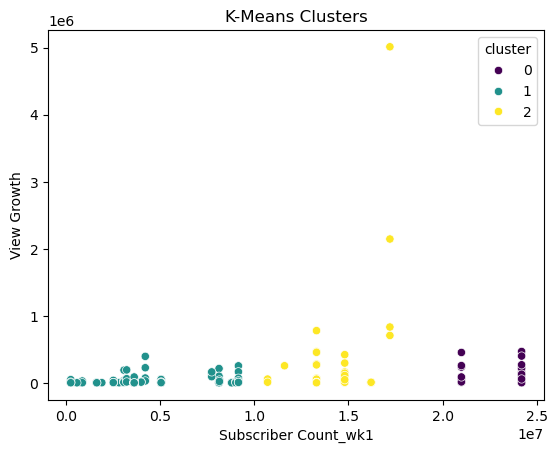


=== PERMUTATION TEST (Like Count_wk1 vs. View Growth) ===
Observed correlation = 0.530
P-value (two-sided) ~ 0.000 (n_perm=1000)

=== OLS WITH INTERACTION ===
                            OLS Regression Results                            
Dep. Variable:       Q('View Growth')   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     38.57
Date:                Wed, 05 Mar 2025   Prob (F-statistic):           2.09e-20
Time:                        18:58:49   Log-Likelihood:                -3450.0
No. Observations:                 246   AIC:                             6908.
Df Residuals:                     242   BIC:                             6922.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                  

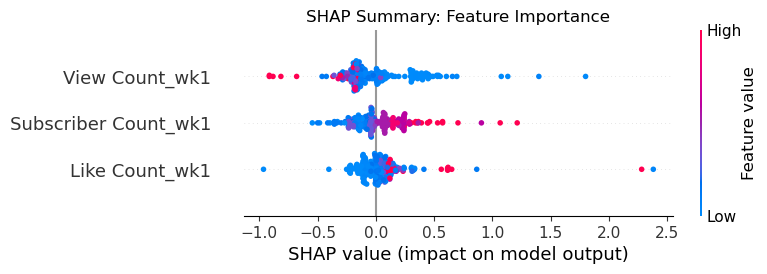


=== DONE ===
We ran Methods 2–6 with the hierarchical model fix referencing 'Channel Name_wk1'.


In [30]:
###############################################################################
# FINAL SCRIPT (Methods 2–6), WITH HIERARCHICAL MODEL FIX
###############################################################################

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
import random
from sklearn.ensemble import GradientBoostingRegressor
import shap

###############################################################################
# 1) LOAD & MERGE YOUR TWO-SNAPSHOT DATA
###############################################################################
df_wk1 = pd.read_csv("526 1.csv")
df_wk2 = pd.read_csv("526 2.csv")

df_merged = pd.merge(df_wk1, df_wk2, on="Video Link", suffixes=("_wk1","_wk2"))

# Convert relevant columns to numeric
num_cols_wk1 = ["Subscriber Count_wk1", "Total Videos_wk1", "Total Views_wk1",
                "View Count_wk1", "Like Count_wk1", "Comment Count_wk1"]
num_cols_wk2 = ["Subscriber Count_wk2", "Total Videos_wk2", "Total Views_wk2",
                "View Count_wk2", "Like Count_wk2", "Comment Count_wk2"]

for col in num_cols_wk1 + num_cols_wk2:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

df_merged.dropna(subset=num_cols_wk1 + num_cols_wk2, inplace=True)

# Create absolute growth columns
df_merged["View Growth"]    = df_merged["View Count_wk2"] - df_merged["View Count_wk1"]
df_merged["Like Growth"]    = df_merged["Like Count_wk2"] - df_merged["Like Count_wk1"]
df_merged["Comment Growth"] = df_merged["Comment Count_wk2"] - df_merged["Comment Count_wk1"]

# Create ratio growth columns (avoid division by zero)
df_merged["View Growth Ratio"] = np.where(
    df_merged["View Count_wk1"]>0,
    df_merged["View Count_wk2"] / df_merged["View Count_wk1"] - 1,
    np.nan
)
df_merged["Like Growth Ratio"] = np.where(
    df_merged["Like Count_wk1"]>0,
    df_merged["Like Count_wk2"] / df_merged["Like Count_wk1"] - 1,
    np.nan
)
df_merged["Comment Growth Ratio"] = np.where(
    df_merged["Comment Count_wk1"]>0,
    df_merged["Comment Count_wk2"] / df_merged["Comment Count_wk1"] - 1,
    np.nan
)

df_merged.dropna(subset=["View Growth Ratio","Like Growth Ratio","Comment Growth Ratio"], inplace=True)

print("=== HEAD OF MERGED DATA (WITH GROWTH COLUMNS) ===")
print(df_merged.head())

###############################################################################
# METHOD 2: Hierarchical (Multi-Level) Modeling - FIXED
###############################################################################
def method_2_hierarchical_model(df_merged):
    """
    Minimal example with statsmodels MixedLM (random intercept for each channel).
    We reference 'Channel Name_wk1' since 'Channel Name' does not exist in df_merged.
    """
    # Create numeric ID for channels from "Channel Name_wk1"
    df_merged["channel_id"] = df_merged["Channel Name_wk1"].astype("category").cat.codes
    
    # We'll do: View Growth ~ SubscriberCount_wk1 + random intercept by channel
    endog = df_merged["View Growth"]
    exog = sm.add_constant(df_merged["Subscriber Count_wk1"])
    groups = df_merged["channel_id"]  # random intercept grouping
    
    md = sm.MixedLM(endog, exog, groups=groups)
    mdf = md.fit()
    print("\n=== HIERARCHICAL MODEL (MixedLM) ===")
    print(mdf.summary())

###############################################################################
# METHOD 3: Clustering & Unsupervised
###############################################################################
def method_3_clustering(df_merged):
    features = ["Subscriber Count_wk1", "View Count_wk1", "Like Count_wk1"]
    X = df_merged[features].copy()
    
    kmeans = KMeans(n_clusters=3, random_state=42)
    df_merged["cluster"] = kmeans.fit_predict(X)
    
    cluster_means = df_merged.groupby("cluster")["View Growth"].mean()
    print("\n=== K-Means Clusters: Average View Growth by Cluster ===")
    print(cluster_means)
    
    plt.figure()
    sns.scatterplot(data=df_merged, x="Subscriber Count_wk1", y="View Growth",
                    hue="cluster", palette="viridis")
    plt.title("K-Means Clusters")
    plt.show()

###############################################################################
# METHOD 4: Permutation Test
###############################################################################
def method_4_permutation_test(df_merged, n_perm=1000):
    x = df_merged["Like Count_wk1"].values
    y = df_merged["View Growth"].values
    
    obs_corr = np.corrcoef(x, y)[0,1]
    
    count_more_extreme = 0
    for _ in range(n_perm):
        x_perm = np.random.permutation(x)
        perm_corr = np.corrcoef(x_perm, y)[0,1]
        if abs(perm_corr) >= abs(obs_corr):
            count_more_extreme += 1
    
    p_value = count_more_extreme / n_perm
    print("\n=== PERMUTATION TEST (Like Count_wk1 vs. View Growth) ===")
    print(f"Observed correlation = {obs_corr:.3f}")
    print(f"P-value (two-sided) ~ {p_value:.3f} (n_perm={n_perm})")

###############################################################################
# METHOD 5: Interaction Terms (OLS)
###############################################################################
def method_5_interactions(df_merged):
    formula = "Q('View Growth') ~ Q('Subscriber Count_wk1') * Q('Like Count_wk1')"
    model = smf.ols(formula=formula, data=df_merged).fit()
    print("\n=== OLS WITH INTERACTION ===")
    print(model.summary())

###############################################################################
# METHOD 6: Gradient Boosting + SHAP
###############################################################################
def method_6_boosting_shap(df_merged):
    features = ["Subscriber Count_wk1", "View Count_wk1", "Like Count_wk1"]
    target = "View Growth Ratio"
    
    df_local = df_merged.dropna(subset=features + [target]).copy()
    X = df_local[features]
    y = df_local[target]
    
    gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gbr.fit(X, y)
    
    preds = gbr.predict(X)
    mse = np.mean((preds - y)**2)
    r2 = 1 - np.sum((preds-y)**2)/np.sum((y-y.mean())**2)
    
    print("\n=== GRADIENT BOOSTING REGRESSOR (Predicting View Growth Ratio) ===")
    print(f"MSE: {mse:.3f}, R^2: {r2:.3f}")
    
    explainer = shap.Explainer(gbr, X)
    shap_values = explainer(X)
    
    shap.summary_plot(shap_values, X, show=False)
    plt.title("SHAP Summary: Feature Importance")
    plt.show()

###############################################################################
# 2) CALL EACH METHOD IN SEQUENCE (2–6)
###############################################################################

# 2.1) Hierarchical Model
method_2_hierarchical_model(df_merged)

# 2.2) Clustering
method_3_clustering(df_merged)

# 2.3) Permutation Test
method_4_permutation_test(df_merged, n_perm=1000)

# 2.4) OLS with Interaction
method_5_interactions(df_merged)

# 2.5) Gradient Boosting + SHAP
method_6_boosting_shap(df_merged)

print("\n=== DONE ===")
print("We ran Methods 2–6 with the hierarchical model fix referencing 'Channel Name_wk1'.")


In [1]:
###############################################################################
# 0) IMPORTS & SETUP
###############################################################################
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

###############################################################################
# 1) LOAD & PREP DATA
###############################################################################
df_wk1 = pd.read_csv("526 1.csv")
df_wk2 = pd.read_csv("526 2.csv")

# Convert "Video Posted" to datetime, remove timezone if needed
df_wk1["Video Posted"] = pd.to_datetime(df_wk1["Video Posted"], utc=True).dt.tz_localize(None)
df_wk2["Video Posted"] = pd.to_datetime(df_wk2["Video Posted"], utc=True).dt.tz_localize(None)

# Suppose your snapshots are on 2025-02-20 and 2025-02-27
snapshot_wk1 = pd.to_datetime("2025-02-20")
snapshot_wk2 = pd.to_datetime("2025-02-27")

# Compute days since posted
df_wk1["daysSincePosted_wk1"] = (snapshot_wk1 - df_wk1["Video Posted"]).dt.days
df_wk2["daysSincePosted_wk2"] = (snapshot_wk2 - df_wk2["Video Posted"]).dt.days

# Convert columns to numeric
num_cols = ["Subscriber Count","Total Videos","Total Views",
            "View Count","Like Count","Comment Count"]
for col in num_cols:
    df_wk1[col] = pd.to_numeric(df_wk1[col], errors="coerce")
    df_wk2[col] = pd.to_numeric(df_wk2[col], errors="coerce")

df_wk1.dropna(subset=num_cols + ["daysSincePosted_wk1"], inplace=True)
df_wk2.dropna(subset=num_cols + ["daysSincePosted_wk2"], inplace=True)

# Merge on "Video Link"
df_merged = pd.merge(df_wk1, df_wk2, on="Video Link", suffixes=("_wk1","_wk2"))
df_merged.dropna(subset=["daysSincePosted_wk1","daysSincePosted_wk2"], inplace=True)

###############################################################################
# 2) CHOOSE FEATURES & TARGET
#    We'll predict "View Count_wk2" from some Week1 columns + daysSincePosted_wk1
###############################################################################
feature_cols = [
    "Subscriber Count_wk1",
    "Like Count_wk1",
    "Comment Count_wk1",
    "daysSincePosted_wk1",
    "View Count_wk1"
]
target_col = "View Count_wk2"

# Drop rows with missing data in these columns
df_merged.dropna(subset=feature_cols + [target_col], inplace=True)

###############################################################################
# 3) SPLIT INTO TRAIN/TEST (80/20)
###############################################################################
df_train, df_test = train_test_split(df_merged, test_size=0.20, random_state=42)

print(f"Train set size: {len(df_train)} rows")
print(f"Test set size : {len(df_test)} rows")

###############################################################################
# 4) NEGATIVE BINOMIAL MODEL (STATS) - TRAIN/TEST
###############################################################################
# We'll define a formula referencing columns in df_train
# For negative binomial, you can do something like:
formula_nb = """
Q('View Count_wk2') ~ Q('daysSincePosted_wk1')
 + Q('Subscriber Count_wk1') + Q('Like Count_wk1') + Q('Comment Count_wk1')
 + Q('View Count_wk1')
"""

model_nb = smf.glm(
    formula=formula_nb,
    data=df_train,                   # TRAIN ONLY
    family=sm.families.NegativeBinomial()
)
res_nb = model_nb.fit()

print("\n=== NEGATIVE BINOMIAL (TRAIN) ===")
print(res_nb.summary())

# Predict on TEST
pred_nb = res_nb.predict(df_test)  # Predicted mean of NB
y_test_nb = df_test[target_col]

r2_nb = r2_score(y_test_nb, pred_nb)
mse_nb = mean_squared_error(y_test_nb, pred_nb)

print("\n=== NEGATIVE BINOMIAL: TEST PERFORMANCE ===")
print(f"R^2 = {r2_nb:.3f}")
print(f"MSE = {mse_nb:.3f}")

###############################################################################
# 5) OLS WITH LOG-TRANSFORM OF THE TARGET (TRAIN/TEST)
###############################################################################
# We'll create a new column log_views_wk2 = log(1 + ViewCount_wk2).
df_train["log_views_wk2"] = np.log1p(df_train[target_col])
df_test["log_views_wk2"]  = np.log1p(df_test[target_col])

formula_ols = """
log_views_wk2 ~ daysSincePosted_wk1
 + Q('Subscriber Count_wk1') + Q('Like Count_wk1') + Q('Comment Count_wk1')
 + Q('View Count_wk1')
"""

model_ols = smf.ols(formula=formula_ols, data=df_train).fit()
print("\n=== OLS (log-transform) - TRAIN ===")
print(model_ols.summary())

# Predict on TEST in log scale, then transform back
pred_ols_log = model_ols.predict(df_test)  # log scale predictions
pred_ols = np.expm1(pred_ols_log)          # revert to original scale

y_test_ols = df_test[target_col]
r2_ols = r2_score(y_test_ols, pred_ols)
mse_ols = mean_squared_error(y_test_ols, pred_ols)

print("\n=== OLS (log-transform): TEST PERFORMANCE ===")
print(f"R^2 = {r2_ols:.3f}")
print(f"MSE = {mse_ols:.3f}")

###############################################################################
# 6) RANDOM FOREST (TRAIN/TEST)
###############################################################################
X_train = df_train[feature_cols]
y_train = df_train[target_col]

X_test = df_test[feature_cols]
y_test = df_test[target_col]

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, pred_rf)
mse_rf = mean_squared_error(y_test, pred_rf)

print("\n=== RANDOM FOREST (Predicting 'View Count_wk2') ===")
print(f"R^2 on test set: {r2_rf:.3f}")
print(f"MSE on test set: {mse_rf:.3f}")

# Feature importances
importances = rf.feature_importances_
for feat, imp in zip(feature_cols, importances):
    print(f"  {feat} importance: {imp:.3f}")

###############################################################################
# 7) INTERPRETATION
###############################################################################
# - Negative Binomial: see summary for coefficient signs & significance, then
#   check R^2 & MSE on the test set.
# - OLS(log-transform): look at the coefficient of daysSincePosted_wk1, etc.
#   Then we exponentiate predictions to compare on the original scale (R^2, MSE).
# - Random Forest: check R^2, MSE, and feature importances for the test set.

print("\n=== DONE ===")
print("We performed train/test splits for NB, OLS(log), and RF, each trained on 80% and tested on 20%.")


Train set size: 214 rows
Test set size : 54 rows

=== NEGATIVE BINOMIAL (TRAIN) ===
                  Generalized Linear Model Regression Results                  
Dep. Variable:     Q('View Count_wk2')   No. Observations:                  214
Model:                             GLM   Df Residuals:                      208
Model Family:         NegativeBinomial   Df Model:                            5
Link Function:                     Log   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -2787.1
Date:                 Wed, 05 Mar 2025   Deviance:                       297.20
Time:                         22:27:36   Pearson chi2:                     167.
No. Iterations:                     57   Pseudo R-squ. (CS):             0.8489
Covariance Type:             nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [9]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

###############################################################################
# 1) LOAD & PREP DATA (EXAMPLE)
###############################################################################
# Suppose you already have df_merged with columns like:
#   "View Count_wk1", "View Count_wk2", "Subscriber Count_wk1",
#   "Like Count_wk1", "Comment Count_wk1", "daysSincePosted_wk2", ...
# In real usage, you'd do something like:
# df_wk1 = pd.read_csv("526 1.csv")
# df_wk2 = pd.read_csv("526 2.csv")
# df_merged = pd.merge(df_wk1, df_wk2, on="Video Link", suffixes=("_wk1","_wk2"))
# ... plus numeric conversion and dropping NaNs ...
# For brevity, we'll assume df_merged is already prepared.

###############################################################################
# 2) DEFINE FORMULA (NO INTERCEPT, USING -1)
###############################################################################
formula = """
Q('View Count_wk2') ~ -1

 + Q('Subscriber Count_wk1')
 + Q('Like Count_wk1')
 + Q('Comment Count_wk1')
 + Q('daysSincePosted_wk2')
"""

###############################################################################
# 3) SPLIT INTO TRAIN/TEST (80/20)
###############################################################################
train_df, test_df = train_test_split(df_merged, test_size=0.2, random_state=42)
print(f"Train set: {len(train_df)} rows, Test set: {len(test_df)} rows")

###############################################################################
# 4) FIT THE MODEL ON THE TRAINING SET
###############################################################################
model_train = smf.ols(formula=formula, data=train_df).fit()

print("\n=== OLS MODEL SUMMARY (TRAIN) ===")
print(model_train.summary())

###############################################################################
# 5) PERFORM F-TESTS ON THE TRAINING MODEL
###############################################################################
# a) 'Subscriber Count_wk1'
ftest_subscriber = model_train.f_test("Q('Subscriber Count_wk1') = 0")
print("\n=== F-TEST: Subscriber Count_wk1 ===")
print(ftest_subscriber)

# b) 'daysSincePosted_wk2'
ftest_days = model_train.f_test("Q('daysSincePosted_wk2') = 0")
print("\n=== F-TEST: daysSincePosted_wk2 ===")
print(ftest_days)

# c) 'Like Count_wk1'
ftest_likes = model_train.f_test("Q('Like Count_wk1') = 0")
print("\n=== F-TEST: Like Count_wk1 ===")
print(ftest_likes)

# d) 'Comment Count_wk1'
ftest_comment = model_train.f_test("Q('Comment Count_wk1') = 0")
print("\n=== F-TEST: Comment Count_wk1 ===")
print(ftest_comment)

# e) 'View Count_wk1'
# ftest_views = model_train.f_test("Q('View Count_wk1') = 0")
# print("\n=== F-TEST: View Count_wk1 ===")
# print(ftest_views)

###############################################################################
# 6) PREDICT ON THE TEST SET & EVALUATE
###############################################################################
test_df = test_df.copy()
test_df["predicted_ViewCount_wk2"] = model_train.predict(test_df)

# Mean Squared Error
mse = mean_squared_error(test_df["View Count_wk2"], test_df["predicted_ViewCount_wk2"])

# Out-of-sample R²
r2_out = r2_score(test_df["View Count_wk2"], test_df["predicted_ViewCount_wk2"])

print("\n=== TEST SET PERFORMANCE ===")
print(f"MSE: {mse:.3f}")
print(f"R^2: {r2_out:.3f}")

###############################################################################
# 7) INTERPRETATION
###############################################################################
# - The model has no intercept, so each variable has its own coefficient.
# - F-tests show whether each predictor is significantly non-zero in the train set.
# - MSE and R^2 show how well the model generalizes to the


Train set: 214 rows, Test set: 54 rows

=== OLS MODEL SUMMARY (TRAIN) ===
                                 OLS Regression Results                                 
Dep. Variable:     Q('View Count_wk2')   R-squared (uncentered):                   0.873
Model:                             OLS   Adj. R-squared (uncentered):              0.871
Method:                  Least Squares   F-statistic:                              361.9
Date:                 Wed, 05 Mar 2025   Prob (F-statistic):                    5.69e-93
Time:                         22:36:14   Log-Likelihood:                         -3086.0
No. Observations:                  214   AIC:                                      6180.
Df Residuals:                      210   BIC:                                      6193.
Df Model:                            4                                                  
Covariance Type:             nonrobust                                                  
                                coef

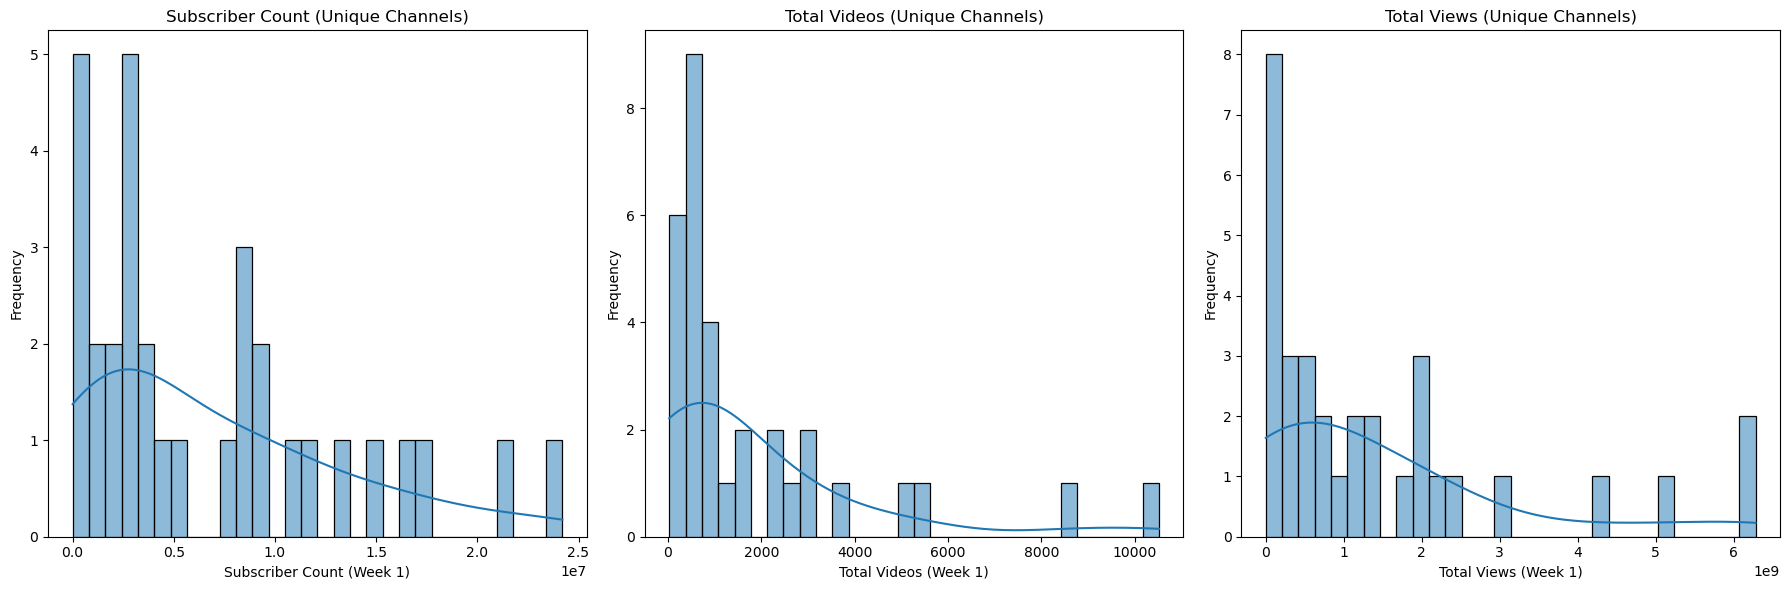

In [33]:

import matplotlib.pyplot as plt
import seaborn as sns

# Week 1: Remove duplicate channels
df_unique_wk1 = df_merged.drop_duplicates(subset=['Channel Name_wk1'])

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Subscriber Count distribution for Week 1
sns.histplot(df_unique_wk1['Subscriber Count_wk1'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Subscriber Count (Unique Channels)')
axes[0].set_xlabel('Subscriber Count (Week 1)')
axes[0].set_ylabel('Frequency')

# Total Videos distribution for Week 1
sns.histplot(df_unique_wk1['Total Videos_wk1'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Total Videos (Unique Channels)')
axes[1].set_xlabel('Total Videos (Week 1)')
axes[1].set_ylabel('Frequency')

# Total Views distribution for Week 1
sns.histplot(df_unique_wk1['Total Views_wk1'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Total Views (Unique Channels)')
axes[2].set_xlabel('Total Views (Week 1)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [34]:

df_merged.columns

Index(['Channel Name_wk1', 'Subscriber Count_wk1', 'Total Videos_wk1',
       'Total Views_wk1', 'View Count_wk1', 'Like Count_wk1',
       'Comment Count_wk1', 'Video Posted_wk1', 'Video Link',
       'daysSincePosted_wk1', 'Channel Name_wk2', 'Subscriber Count_wk2',
       'Total Videos_wk2', 'Total Views_wk2', 'View Count_wk2',
       'Like Count_wk2', 'Comment Count_wk2', 'Video Posted_wk2',
       'daysSincePosted_wk2', 'log_views_wk2'],
      dtype='object')